# From Chat to Tools: Function Calling

> The previous sections covered how to train a model: how training loss is computed, how data is processed, how parameters are updated efficiently. Once trained, the model can already generate fluent text and answer common-knowledge questions.
>
> But there is a class of questions it cannot answer — today's weather, 357 times 289, the current commit count of a particular repository. All of these require external information or external computation. This section covers Function Call: through special data construction and training, the model learns to output structured call requests, which an external program executes and feeds the results back to the model.


LLM training data has a temporal cutoff, after which events are unknown to the model. LLMs are also not good at precise numerical computation — asking the model to directly compute 357 times 289 may produce a result that looks reasonable but is in fact wrong. These two limitations combined mean that pure text generation is insufficient in many practical scenarios.

The Function Call approach adds an external interface to the model. The model itself performs no operation; it only generates a structured piece of JSON specifying which function to call and what arguments to pass. This JSON is parsed and executed by an external program (for example, actually querying a weather API or invoking a calculator), and the execution result is then appended back into the conversation history. The model produces its final natural-language reply based on that result.

This capability is acquired through dedicated training; the model is not born knowing how to output JSON. Starting from the problem, the following sections walk through the complete Function Call flow and then look at how to train this capability.


## Section Highlights

After studying this section, you should be able to answer the following questions:

1. In which scenarios does an LLM need external tools?
2. What is the complete Function Call flow?
3. When a conversation requires multiple tool calls, how are parallel and sequential calls handled?
4. How do you train a model that supports Function Call?
5. What do the role and content fields of a message mean?
6. How do messages become text the model can read?
7. What is the relationship among input tokens, output tokens, and context length?
8. What are the common failure modes of Function Call?
9. From Function Call to MCP, what is the evolution path of the tool-calling ecosystem?

## 1. Why Function Call Is Needed

An LLM's knowledge comes from training data, and training data has a temporal cutoff. Asked "what is the temperature in Beijing today", the model gives a vague answer based on weather statistics seen during training, but it cannot possibly know the real weather today. This is the first limitation — knowledge cutoff.

The second limitation is numerical computation. The fundamental operations of a Transformer are matrix multiplication and softmax, which are not suited to precise multi-digit multiplication. Asking the model to directly compute 357 × 289 often produces a wrong answer. The model's answer looks reasonable (the order of magnitude is right, the last digit may be right), but the middle digits are often incorrect.

The code below simulates these two failures.


In [1]:
# Simulate two typical LLM failures: knowledge cutoff + numerical computation errors

# Scenario 1: knowledge cutoff
# The model's training data is in the past, so it cannot know "today's" real data
def fake_llm_today_weather():
    # An LLM that does not understand tools is asked about today's weather
    return "I cannot query Beijing's weather in real time, but the temperature this season is usually between 20-30C."

print("=== Failure 1: knowledge cutoff ===")
print("User: What is the temperature in Beijing today?")
print(f"Model: {fake_llm_today_weather()}")
print("Problem: the model does not know today's real weather and can only give a vague guess")
print()

# Scenario 2: numerical computation error
# Simulate a "model" that gets arithmetic wrong — it outputs an answer that looks reasonable but is wrong
def fake_llm_multiply(a, b):
    # Simulate an LLM computing multiplication; it may get it wrong
    correct = a * b
    wrong = correct + 1234  # deliberately give a wrong answer
    return wrong

a, b = 357, 289
correct = a * b
llm_answer = fake_llm_multiply(a, b)
print("=== Failure 2: numerical computation error ===")
print(f"User: what is {a} x {b}?")
print(f"Model: {llm_answer}")
print(f"Correct: {correct}")
print(f"Gap: the model's answer is {llm_answer - correct} higher than the correct answer")
print()
print("Conclusion: the model alone cannot solve these two kinds of problems. It needs an external interface.")


=== Failure 1: knowledge cutoff ===
User: What is the temperature in Beijing today?
Model: I cannot query Beijing's weather in real time, but the temperature this season is usually between 20-30C.
Problem: the model does not know today's real weather and can only give a vague guess

=== Failure 2: numerical computation error ===
User: what is 357 x 289?
Model: 104407
Correct: 103173
Gap: the model's answer is 1234 higher than the correct answer

Conclusion: the model alone cannot solve these two kinds of problems. It needs an external interface.


## 2. The Complete Function Call Flow

The core idea of Function Call is to separate "execution" from "decision":

- Decision (whether to call a tool, which one, what arguments to pass) is done by the model
- Execution (actually querying the weather, doing arithmetic, querying a database) is done by an external program

The complete flow has six steps. Let us walk through a concrete example: the user asks "What is the temperature in Beijing today?".

Step 1: define the tools. Each tool is a JSON description telling the model what the tool is called, what it does, and what parameters it needs.
Step 2: inject the tool description into the system prompt. The model sees this description before generating its reply.
Step 3: the model generates a reply. If it decides a tool is needed, instead of natural language it outputs a structured piece of JSON.
Step 4: the external program parses this JSON and calls the corresponding function.
Step 5: the execution result is wrapped as a new conversation message and added to the conversation history.
Step 6: the model generates the final natural-language reply based on the complete conversation history (including the tool result).


In [2]:
# Step 1: define the available tools
# Each tool is a dict with three parts: name / description / parameters

import json

tools = [
    {
        "name": "get_weather",
        "description": "Query the current weather for a given city",
        "parameters": {
            "city": {"type": "string", "description": "City name"},
            "unit": {"type": "string", "enum": ["celsius", "fahrenheit"], "description": "Temperature unit"}
        }
    },
    {
        "name": "calculate",
        "description": "Evaluate a mathematical expression",
        "parameters": {
            "expression": {"type": "string", "description": "Mathematical expression"}
        }
    }
]

print("=== Defined tools ===")
for t in tools:
    print(f"\nTool name: {t['name']}")
    print(f"  Description: {t['description']}")
    print(f"  Parameters:")
    for pname, pinfo in t['parameters'].items():
        print(f"    {pname} ({pinfo['type']}): {pinfo['description']}")


=== Defined tools ===

Tool name: get_weather
  Description: Query the current weather for a given city
  Parameters:
    city (string): City name
    unit (string): Temperature unit

Tool name: calculate
  Description: Evaluate a mathematical expression
  Parameters:
    expression (string): Mathematical expression


In [3]:
# Step 2: assemble the tool descriptions into the system prompt
# This text is visible to the model, which uses it to decide whether and which tool to call

def build_system_prompt(tools):
    # Build a system prompt from the tool list
    lines = ["You are an assistant that can use the following tools. When external information is needed, output a call request in JSON format.", ""]
    lines.append("Available tools:")
    for t in tools:
        lines.append(f"\nTool: {t['name']}")
        lines.append(f"  Description: {t['description']}")
        lines.append(f"  Parameters:")
        for pname, pinfo in t['parameters'].items():
            lines.append(f"    - {pname}: {pinfo['description']}")
    return "\n".join(lines)

system_prompt = build_system_prompt(tools)
print("=== System Prompt (the model sees this) ===")
print(system_prompt)


=== System Prompt (the model sees this) ===
You are an assistant that can use the following tools. When external information is needed, output a call request in JSON format.

Available tools:

Tool: get_weather
  Description: Query the current weather for a given city
  Parameters:
    - city: City name
    - unit: Temperature unit

Tool: calculate
  Description: Evaluate a mathematical expression
  Parameters:
    - expression: Mathematical expression


In [4]:
# Step 3: simulate the model generating a JSON call request
# In practice this is the token sequence produced by the model's forward pass; here we hand-simulate a reasonable output

user_query = "What is the temperature in Beijing today?"

# Suppose that, after training, the model faced with this user query and the tool list above outputs this JSON
model_output = json.dumps({
    "tool_call": {
        "name": "get_weather",
        "arguments": {"city": "Beijing", "unit": "celsius"}
    }
}, ensure_ascii=False, indent=2)

print("=== Model output ===")
print(f"User: {user_query}")
print("Instead of natural language, the model outputs JSON:")
print(model_output)
print()
print("Key observation: the model decides that external information is needed and selects the get_weather tool, filling in city='Beijing'.")


=== Model output ===
User: What is the temperature in Beijing today?
Instead of natural language, the model outputs JSON:
{
  "tool_call": {
    "name": "get_weather",
    "arguments": {
      "city": "Beijing",
      "unit": "celsius"
    }
  }
}

Key observation: the model decides that external information is needed and selects the get_weather tool, filling in city='Beijing'.


In [5]:
# Step 4 + Step 5: an external program executes the tool, and the result is appended to the conversation history

# Simulate the real implementation of the tools
def execute_tool(name, arguments):
    # Execute the corresponding function based on the tool name
    if name == "get_weather":
        # In practice this would call a real weather API
        return {"temperature": 22, "condition": "sunny", "humidity": 45}
    elif name == "calculate":
        # In practice this would call a real calculator
        return {"result": eval(arguments["expression"])}
    return {"error": f"Unknown tool: {name}"}

# Parse the model's JSON output and execute the corresponding tool
parsed = json.loads(model_output)
call = parsed["tool_call"]
tool_result = execute_tool(call["name"], call["arguments"])

print("=== Tool execution ===")
print(f"Call: {call['name']}({call['arguments']})")
print(f"Return: {tool_result}")
print()

# Build the full conversation history, adding the tool result as a new message
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
    {"role": "assistant", "content": model_output},
    {"role": "tool", "name": call["name"], "content": json.dumps(tool_result, ensure_ascii=False)},
]

print("=== Full conversation history (now includes the tool result) ===")
for m in messages:
    role = m["role"]
    content = m["content"]
    if len(content) > 80:
        content = content[:80] + "..."
    print(f"[{role}] {content}")


=== Tool execution ===
Call: get_weather({'city': 'Beijing', 'unit': 'celsius'})
Return: {'temperature': 22, 'condition': 'sunny', 'humidity': 45}

=== Full conversation history (now includes the tool result) ===
[system] You are an assistant that can use the following tools. When external information...
[user] What is the temperature in Beijing today?
[assistant] {
  "tool_call": {
    "name": "get_weather",
    "arguments": {
      "city": "...
[tool] {"temperature": 22, "condition": "sunny", "humidity": 45}


In [6]:
# Step 6: the model generates the final natural-language reply based on the full conversation history

# Simulate the model's final reply
final_reply = "Beijing is 22C and sunny today."

print("=== Final reply ===")
print(f"Model: {final_reply}")
print()
print("Key observation: after seeing the tool return temperature=22 and weather=sunny, the model composes them into a natural-language sentence.")
print("What the user perceives is an ordinary answer; the details of the tool call are hidden.")


=== Final reply ===
Model: Beijing is 22C and sunny today.

Key observation: after seeing the tool return temperature=22 and weather=sunny, the model composes them into a natural-language sentence.
What the user perceives is an ordinary answer; the details of the tool call are hidden.


## 3. Multi-Tool Scenarios

In real scenarios, a single question often needs multiple tools. For example, the user asks "What is the temperature in Beijing today? Also, what is 357 x 289?", and the model needs to call both get_weather and calculate.

There are two cases here, handled differently.

Parallel calls: the two tools have no dependency between them, so order does not affect the result. The model can generate multiple call requests in a single output, the external program executes them concurrently, and all results are fed back at once. This has lower latency.

Sequential calls: the arguments of the second tool depend on the result of the first. The model must call the first tool, see the result, and only then decide whether to call the second and what arguments to pass. For example, "check the temperature in Beijing today, then tell me what to wear" — the second call (clothing recommendation) depends on the result of the first call (weather). This case must proceed over multiple rounds.


In [7]:
# Parallel calls: generate multiple tool call requests at once

user_query = "What is the temperature in Beijing today? Also, what is 357 x 289?"

# The model outputs multiple calls in one go
model_output = json.dumps({
    "tool_calls": [
        {"name": "get_weather", "arguments": {"city": "Beijing", "unit": "celsius"}},
        {"name": "calculate", "arguments": {"expression": "357*289"}}
    ]
}, ensure_ascii=False, indent=2)

print("=== Parallel call ===")
print(f"User: {user_query}")
print("Model output:")
print(model_output)
print()

# The external program parses and executes them one by one (in practice they can run concurrently)
parsed = json.loads(model_output)
for call in parsed["tool_calls"]:
    result = execute_tool(call["name"], call["arguments"])
    print(f"Execute {call['name']} -> {result}")

print()
print("Key observation: the model output two calls at once, and there is no dependency between them.")
print("The external program can execute them concurrently and feed both results back to the model at once.")


=== Parallel call ===
User: What is the temperature in Beijing today? Also, what is 357 x 289?
Model output:
{
  "tool_calls": [
    {
      "name": "get_weather",
      "arguments": {
        "city": "Beijing",
        "unit": "celsius"
      }
    },
    {
      "name": "calculate",
      "arguments": {
        "expression": "357*289"
      }
    }
  ]
}

Execute get_weather -> {'temperature': 22, 'condition': 'sunny', 'humidity': 45}
Execute calculate -> {'result': 103173}

Key observation: the model output two calls at once, and there is no dependency between them.
The external program can execute them concurrently and feed both results back to the model at once.


In [8]:
# Sequential calls: the second call depends on the result of the first

user_query = "What is the temperature in Beijing today? What should I wear?"

# Round 1: the model first calls the weather tool
first_call = json.dumps({
    "tool_call": {"name": "get_weather", "arguments": {"city": "Beijing", "unit": "celsius"}}
}, ensure_ascii=False)

print("=== Sequential call ===")
print(f"User: {user_query}")
print("\nRound 1 model output:")
print(first_call)

weather_result = execute_tool("get_weather", {"city": "Beijing", "unit": "celsius"})
print(f"\nTool result: {weather_result}")
print()

# Round 2: after seeing the weather result, the model decides to call a clothing-suggestion tool
wardrobe_tool_result = {"suggestion": "Long-sleeve shirt with a light jacket"}
print("Round 2 model output: based on weather 22C sunny, call the clothing-suggestion tool")
print(f"Tool result: {wardrobe_tool_result}")
print()
print("Key observation: the round-2 call depends on the round-1 result — the model must first know the temperature before it can suggest clothing.")
print("This dependency means a sequential call must span multiple rounds, with higher latency than parallel calls.")


=== Sequential call ===
User: What is the temperature in Beijing today? What should I wear?

Round 1 model output:
{"tool_call": {"name": "get_weather", "arguments": {"city": "Beijing", "unit": "celsius"}}}

Tool result: {'temperature': 22, 'condition': 'sunny', 'humidity': 45}

Round 2 model output: based on weather 22C sunny, call the clothing-suggestion tool
Tool result: {'suggestion': 'Long-sleeve shirt with a light jacket'}

Key observation: the round-2 call depends on the round-1 result — the model must first know the temperature before it can suggest clothing.
This dependency means a sequential call must span multiple rounds, with higher latency than parallel calls.


## 4. Training a Model That Supports Function Call

A model is not born knowing how to output JSON-formatted tool calls. Faced with a request to "call the get_weather tool", an ordinary pretrained model outputs text that looks like JSON but is not strictly formatted, with arguments possibly fabricated. Making it reliably output a legal JSON call requires dedicated data construction and training.

The training data looks very similar to ordinary instruction-tuning data; the difference is that the assistant's reply contains a tool-call JSON. Let us look at a concrete training sample.


In [9]:
# A complete Function Call training sample

training_sample = {
    "messages": [
        {
            "role": "system",
            "content": "You are an assistant that can use the following tools: get_weather(city) to query the weather; calculate(expression) to compute."
        },
        {
            "role": "user",
            "content": "What is the temperature in Beijing today?"
        },
        {
            "role": "assistant",
            "content": "",
            "tool_call": {"name": "get_weather", "arguments": {"city": "Beijing", "unit": "celsius"}}
        },
        {
            "role": "tool",
            "name": "get_weather",
            "content": '{"temperature": 22, "condition": "sunny"}'
        },
        {
            "role": "assistant",
            "content": "Beijing is 22C and sunny today."
        }
    ]
}

print("=== A Function Call training sample ===")
print(json.dumps(training_sample, ensure_ascii=False, indent=2))
print()
print("This sample contains a full conversation flow: system -> user -> assistant(tool call) -> tool(result) -> assistant(final reply).")
print("Through many such samples, the model learns when to output a tool-call JSON.")


=== A Function Call training sample ===
{
  "messages": [
    {
      "role": "system",
      "content": "You are an assistant that can use the following tools: get_weather(city) to query the weather; calculate(expression) to compute."
    },
    {
      "role": "user",
      "content": "What is the temperature in Beijing today?"
    },
    {
      "role": "assistant",
      "content": "",
      "tool_call": {
        "name": "get_weather",
        "arguments": {
          "city": "Beijing",
          "unit": "celsius"
        }
      }
    },
    {
      "role": "tool",
      "name": "get_weather",
      "content": "{\"temperature\": 22, \"condition\": \"sunny\"}"
    },
    {
      "role": "assistant",
      "content": "Beijing is 22C and sunny today."
    }
  ]
}

This sample contains a full conversation flow: system -> user -> assistant(tool call) -> tool(result) -> assistant(final reply).
Through many such samples, the model learns when to output a tool-call JSON.


### 4.1 How the Loss Is Computed: from template to every token

The training-and-loss notebook walked through the skeleton — render, tokenize, mask — using a single-turn Q&A. A Function Call training sample adds a detail that ordinary conversations do not have: the assistant appears twice, with a tool-result turn in between. So the supervised span is not one contiguous block but two segments — the tool-call JSON and the final reply.

This subsection follows the training sample from the top of this section down to the token level, in four steps, and every step's output can be verified by hand:

```text
Step 1   chat template: messages -> one continuous text with special tokens
Step 2   tokenizer: text -> a token sequence where every token is countable
Step 3   labels: supervised positions keep the token id; input positions become -100
Step 4   cross entropy: each supervised position contributes -log p, averaged over supervised positions only
```

Why is the ignore marker -100 of all things? It is the default `ignore_index` of PyTorch `cross_entropy`: positions marked -100 enter neither the numerator nor the denominator of the loss. Hand-computing cross entropy itself was done in the training-and-loss notebook; here we walk the masked pipeline in pure Python. Real training libraries do exactly the same thing, only with a real tokenizer and template.

In [10]:
# Step 1: render the messages into one continuous text with a simplified chat template
# The format follows the Qwen style: <|im_start|>role\n content <|im_end|>\n
# A real Qwen template also wraps the tool-call JSON in
# <tool_call>...</tool_call> tags; omitted here
def apply_simple_template(sample):
    """Render messages into a list of (text piece, counts toward loss);
    concatenated they form the full training text"""
    segments = []
    for msg in sample["messages"]:
        role = msg["role"]
        # The role marker at the start of each turn tells the model whose turn it is: input
        segments.append((f"<|im_start|>{role}\n", False))
        if role == "assistant" and msg.get("tool_call"):
            # The tool-call JSON is what the model must learn to output: counts
            body = json.dumps(msg["tool_call"], ensure_ascii=False)
            segments.append((body, True))
        elif role == "assistant":
            # The final reply is also content the model must learn: counts
            segments.append((msg["content"], True))
        else:
            # system instructions, user questions, tool results are all inputs
            segments.append((msg["content"], False))
        # The assistant must learn to stop: its <|im_end|> counts too;
        # other roles' end markers are input
        segments.append(("<|im_end|>", role == "assistant"))
        # The newline after the end marker is just layout: input
        segments.append(("\n", False))
    return segments

segments = apply_simple_template(training_sample)
full_text = "".join(text for text, _ in segments)

print("=== Step 1: the full training text rendered by the chat template ===")
print(full_text)
print("--- Key observations ---")
print("Only two spots count toward the loss: the assistant's tool-call JSON and its final reply.")
print("The <|im_start|>assistant at the start of each turn is input: what the model learns")
print("is 'what to output next', not 'it is my turn now'.")
print("But the <|im_end|> at the end of both assistant turns counts: the model must learn")
print("to stop by itself, otherwise generation never ends.")

=== Step 1: the full training text rendered by the chat template ===
<|im_start|>system
You are an assistant that can use the following tools: get_weather(city) to query the weather; calculate(expression) to compute.<|im_end|>
<|im_start|>user
What is the temperature in Beijing today?<|im_end|>
<|im_start|>assistant
{"name": "get_weather", "arguments": {"city": "Beijing", "unit": "celsius"}}<|im_end|>
<|im_start|>tool
{"temperature": 22, "condition": "sunny"}<|im_end|>
<|im_start|>assistant
Beijing is 22C and sunny today.<|im_end|>

--- Key observations ---
Only two spots count toward the loss: the assistant's tool-call JSON and its final reply.
The <|im_start|>assistant at the start of each turn is input: what the model learns
is 'what to output next', not 'it is my turn now'.
But the <|im_end|> at the end of both assistant turns counts: the model must learn
to stop by itself, otherwise generation never ends.


In [11]:
# Step 2: cut the text into a token sequence with a transparent simplified tokenizer
# Only three rules, so every token can be counted by hand:
#   1. <|im_start|> and <|im_end|> each count as exactly 1 token, never split
#   2. A run of ASCII letters/digits/underscore becomes 1 token, e.g. get_weather, 22, celsius
#   3. Every other character (other scripts, punctuation, space, newline) is 1 token each
SPECIALS = ["<|im_start|>", "<|im_end|>"]

def simple_tokenize(text):
    """Cut the text into a token list following the three rules above"""
    tokens = []
    i = 0
    while i < len(text):
        # Rule 1: a special token stays whole
        hit = next((s for s in SPECIALS if text.startswith(s, i)), None)
        if hit is not None:
            tokens.append(hit)
            i += len(hit)
        # Rule 2: English words and numbers stay glued
        elif text[i].isascii() and (text[i].isalnum() or text[i] == "_"):
            j = i
            while j < len(text) and text[j].isascii() and (text[j].isalnum() or text[j] == "_"):
                j += 1
            tokens.append(text[i:j])
            i = j
        # Rule 3: everything else is cut character by character
        else:
            tokens.append(text[i])
            i += 1
    return tokens

# While cutting, carry the mask flag over: tokens from a loss-counting segment all count
token_list, loss_mask = [], []
for seg_text, seg_loss in segments:
    seg_tokens = simple_tokenize(seg_text)
    token_list.extend(seg_tokens)
    loss_mask.extend([seg_loss] * len(seg_tokens))

# Build a small vocab: special tokens fixed at the front, others numbered by first appearance
vocab = {s: k for k, s in enumerate(SPECIALS)}
for t in token_list:
    if t not in vocab:
        vocab[t] = len(vocab)
input_ids = [vocab[t] for t in token_list]

print("=== Step 2: tokenize ===")
print(f"The full training text is cut into {len(token_list)} tokens, vocab size {len(vocab)}")
print("(A real model's vocab is ~150k with finer BPE merges; this one covers only this")
print(" sample, but the pipeline is the same)")
print()
print("Sample a few pieces to see the cuts:")
print("  role header:", simple_tokenize("<|im_start|>assistant\n"))
print("  user message:", simple_tokenize("What is the temperature in Beijing today?"))
print("  final reply:", simple_tokenize("Beijing is 22C and sunny today."))
print()
print("Note: spaces and newlines are tokens too; every quote and brace in the JSON takes one.")
print("That is why a tool call has more output tokens than it looks")
print("(Section 5.3 will count real ones).")

=== Step 2: tokenize ===
The full training text is cut into 150 tokens, vocab size 50
(A real model's vocab is ~150k with finer BPE merges; this one covers only this
 sample, but the pipeline is the same)

Sample a few pieces to see the cuts:
  role header: ['<|im_start|>', 'assistant', '\n']
  user message: ['What', ' ', 'is', ' ', 'the', ' ', 'temperature', ' ', 'in', ' ', 'Beijing', ' ', 'today', '?']
  final reply: ['Beijing', ' ', 'is', ' ', '22C', ' ', 'and', ' ', 'sunny', ' ', 'today', '.']

Note: spaces and newlines are tokens too; every quote and brace in the JSON takes one.
That is why a tool call has more output tokens than it looks
(Section 5.3 will count real ones).


In [12]:
# Step 3: build labels — supervised positions keep the token id, input positions become -100
labels = [tid if m else -100 for tid, m in zip(input_ids, loss_mask)]

# First find the contiguous supervised runs, to mark boundaries in the per-token table
runs = []
start = None
for i, m in enumerate(loss_mask + [False]):
    if m and start is None:
        start = i
    elif not m and start is not None:
        runs.append((start, i - 1))
        start = None
run_names = ["tool-call JSON", "final reply"]

print("=== Step 3: per-token labels table (label = -100 means ignored) ===")
run_no = -1
for i, (tok, lab) in enumerate(zip(token_list, labels)):
    # Announce when entering a supervised run
    if run_no + 1 < len(runs) and i == runs[run_no + 1][0]:
        run_no += 1
        print(f"------ supervised segment {run_no + 1} starts ({run_names[run_no]}) ------")
    print(f"{i:3d} | {repr(tok):>14} | {lab:4d}")
    # Summarize when leaving a supervised run
    if run_no >= 0 and i == runs[run_no][1]:
        n_in_run = i - runs[run_no][0] + 1
        print(f"------ supervised segment {run_no + 1} ends, {n_in_run} tokens ------")

n_valid = sum(1 for l in labels if l != -100)
print()
n_ignored = len(labels) - n_valid
print(f"{len(labels)} positions in total: {n_valid} count toward the loss, {n_ignored} are -100.")
print("The two supervised segments are not contiguous — the whole tool-result turn sits")
print("between them. This is exactly what distinguishes a Function Call sample from an")
print("ordinary single-turn SFT sample.")

=== Step 3: per-token labels table (label = -100 means ignored) ===
  0 | '<|im_start|>' | -100
  1 |       'system' | -100
  2 |           '\n' | -100
  3 |          'You' | -100
  4 |            ' ' | -100
  5 |          'are' | -100
  6 |            ' ' | -100
  7 |           'an' | -100
  8 |            ' ' | -100
  9 |    'assistant' | -100
 10 |            ' ' | -100
 11 |         'that' | -100
 12 |            ' ' | -100
 13 |          'can' | -100
 14 |            ' ' | -100
 15 |          'use' | -100
 16 |            ' ' | -100
 17 |          'the' | -100
 18 |            ' ' | -100
 19 |    'following' | -100
 20 |            ' ' | -100
 21 |        'tools' | -100
 22 |            ':' | -100
 23 |            ' ' | -100
 24 |  'get_weather' | -100
 25 |            '(' | -100
 26 |         'city' | -100
 27 |            ')' | -100
 28 |            ' ' | -100
 29 |           'to' | -100
 30 |            ' ' | -100
 31 |        'query' | -100
 32 |            ' ' | -100
 33 |   

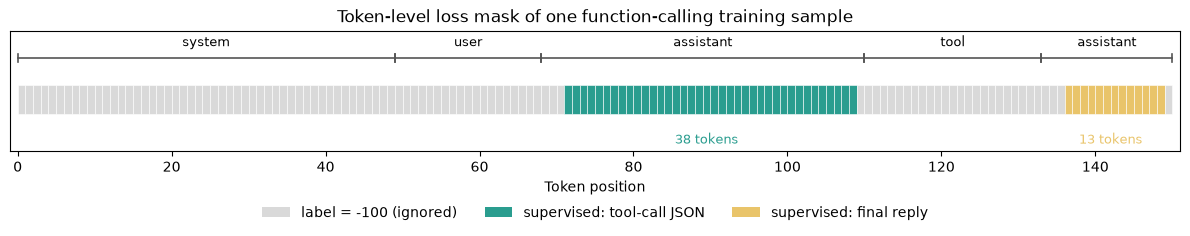

In [13]:
# Visualization: draw the whole token sequence as one timeline;
# the two supervised segments stand out at a glance
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

run_colors = ["#2a9d8f", "#e9c46a"]  # one color per supervised segment
fig, ax = plt.subplots(figsize=(12, 2.8))
for i in range(len(token_list)):
    color = "#d9d9d9"  # default gray = label is -100
    for r, (a, b) in enumerate(runs):
        if a <= i <= b:
            color = run_colors[r]
    ax.barh(0, 1, left=i, height=1, color=color, edgecolor="white", linewidth=0.4)

# Above the strip, mark the token range each message covers (each message starts at a <|im_start|>)
msg_starts = [i for i, t in enumerate(token_list) if t == "<|im_start|>"] + [len(token_list)]
for k in range(len(msg_starts) - 1):
    a, b = msg_starts[k], msg_starts[k + 1] - 1
    role = token_list[a + 1]
    ax.plot([a, b + 1], [1.45, 1.45], color="#555555", linewidth=1.2)
    ax.plot([a, a], [1.3, 1.6], color="#555555", linewidth=1.2)
    ax.plot([b + 1, b + 1], [1.3, 1.6], color="#555555", linewidth=1.2)
    ax.text((a + b + 1) / 2, 1.75, role, ha="center", va="bottom", fontsize=9)

# Under each supervised segment, annotate its token count
for r, (a, b) in enumerate(runs):
    ax.text((a + b) / 2, -1.15, f"{b - a + 1} tokens", ha="center", va="top",
            fontsize=9, color=run_colors[r])

ax.set_xlim(-1, len(token_list) + 1)
ax.set_ylim(-1.8, 2.4)
ax.set_yticks([])
ax.set_xlabel("Token position")
ax.set_title("Token-level loss mask of one function-calling training sample")
legend_items = [Patch(facecolor="#d9d9d9", label="label = -100 (ignored)"),
                Patch(facecolor=run_colors[0], label="supervised: tool-call JSON"),
                Patch(facecolor=run_colors[1], label="supervised: final reply")]
ax.legend(handles=legend_items, loc="upper center", ncol=3,
          bbox_to_anchor=(0.5, -0.35), frameon=False)
plt.tight_layout()
plt.show()

Before step 4, two mechanisms need to be clear.

**shift: the prediction target of position i is the token at position i+1.** labels is as long as input_ids and aligned with it; the one-position shift is applied inside the model (the training-and-loss notebook compared the two equivalent ways: shifting in the data or inside the model). The mask therefore lands on labels — what is supervised is the *target token*. A concrete example: the first token of supervised segment 1 is `{` (position 71), and the context predicting it ends exactly at `<|im_start|>assistant` plus the newline — precisely where the model starts generating at inference time.

**-100: skipped, and kept out of the denominator.** Each supervised position contributes $-\log p(\text{target token} \mid \text{prefix})$, and the total loss is the sum over supervised positions divided by the *number of supervised positions*. The denominator is not the sequence length: this sample has 150 positions but only 51 supervised ones. Averaging over 150 would dilute the loss with input positions and weaken the training signal of "what to output where".

In PyTorch the two mechanisms collapse into one line: `F.cross_entropy(shift_logits, shift_labels, ignore_index=-100)`.

=== Hand computation: the first supervised position ===
Logits at position 70 predict the token at position 71: '{'
First 5 logits (out of 50): [0.32, -0.06, 0.25, 1.41, -0.6]
After softmax, probability of the correct token: p = 0.0166
Loss at this position = -log(p) = 4.0960
Matches per_token_loss[70]: 4.0960

149 prediction positions, 51 supervised, the rest all -100
Correct average (denominator = 51 supervised): 4.4056
Wrong average (denominator = all 149 positions): 1.5080

Key observation 1: random logits give an average loss of 4.4, close to log(vocab size) = 3.91 — an untrained model guesses blindly.
Key observation 2: with the wrong denominator the loss silently shrinks.
Training libraries all average over supervised positions.



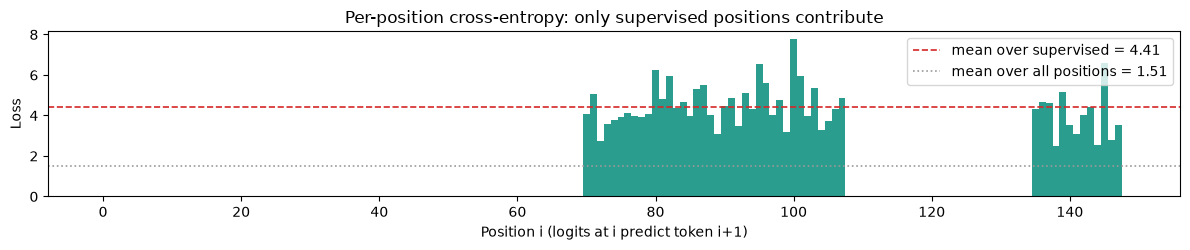

In [14]:
# Step 4: per-position cross entropy, averaged over supervised positions only
# In real training the logits come from the model's forward pass; here a fixed-seed random
# vector stands in. The values themselves are meaningless — the point is how -100 is skipped.
import math
import random

random.seed(42)

def softmax(xs):
    """Turn a row of logits into a probability distribution (subtract max to avoid overflow)"""
    m = max(xs)
    exps = [math.exp(x - m) for x in xs]
    return [e / sum(exps) for e in exps]

# Give every prediction position a row of logits: logits at position i predict labels[i + 1]
n_predict = len(labels) - 1
all_logits = [[random.gauss(0, 1) for _ in range(len(vocab))] for _ in range(n_predict)]

per_token_loss = []
for i in range(n_predict):
    target = labels[i + 1]
    if target == -100:
        per_token_loss.append(None)  # None = skipped by the mask
        continue
    p_correct = softmax(all_logits[i])[target]
    per_token_loss.append(-math.log(p_correct))

# Hand-compute the first supervised position to see where a single position's loss comes from
first_pos = next(i for i, l in enumerate(per_token_loss) if l is not None)
target = labels[first_pos + 1]
probs = softmax(all_logits[first_pos])
print("=== Hand computation: the first supervised position ===")
target_tok = repr(token_list[first_pos + 1])
print(f"Logits at position {first_pos} predict the token at position {first_pos + 1}: {target_tok}")
print(f"First 5 logits (out of {len(vocab)}): {[round(x, 2) for x in all_logits[first_pos][:5]]}")
print(f"After softmax, probability of the correct token: p = {probs[target]:.4f}")
print(f"Loss at this position = -log(p) = {-math.log(probs[target]):.4f}")
print(f"Matches per_token_loss[{first_pos}]: {per_token_loss[first_pos]:.4f}")
print()

valid_losses = [l for l in per_token_loss if l is not None]
print(f"{n_predict} prediction positions, {len(valid_losses)} supervised, the rest all -100")
mean_loss = sum(valid_losses) / len(valid_losses)
print(f"Correct average (denominator = {len(valid_losses)} supervised): {mean_loss:.4f}")
wrong_mean = sum(valid_losses) / n_predict
print(f"Wrong average (denominator = all {n_predict} positions): {wrong_mean:.4f}")
print()
print(f"Key observation 1: random logits give an average loss of {mean_loss:.1f}, close to "
      f"log(vocab size) = {math.log(len(vocab)):.2f} — an untrained model guesses blindly.")
print("Key observation 2: with the wrong denominator the loss silently shrinks.")
print("Training libraries all average over supervised positions.")
print()

# Per-position loss visualization: gray = skipped by the mask, teal = supervised
plt.figure(figsize=(12, 2.6))
heights = [l if l is not None else 0 for l in per_token_loss]
bar_colors = ["#2a9d8f" if l is not None else "#e0e0e0" for l in per_token_loss]
plt.bar(range(n_predict), heights, color=bar_colors, width=1.0)
plt.axhline(mean_loss, color="#d62828", linestyle="--", linewidth=1.2,
            label=f"mean over supervised = {mean_loss:.2f}")
plt.axhline(wrong_mean, color="#999999", linestyle=":", linewidth=1.2,
            label=f"mean over all positions = {wrong_mean:.2f}")
plt.xlabel("Position i (logits at i predict token i+1)")
plt.ylabel("Loss")
plt.title("Per-position cross-entropy: only supervised positions contribute")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 4.2 Where the Training Data Comes From

Constructing training samples is the most time-consuming part of Function Call training. There are three common data sources:

| Source | Approach | Pros and cons |
|:---|:---|:---|
| Human annotation | Annotators see the tool list and write "user question + expected tool call" pairs | High quality, but expensive and hard to scale |
| Strong-model distillation | A model such as GPT-4 that already supports tool calls generates call samples, which are then used as training data | Easy to scale, but capped by the strong model's ability |
| Real logs | Filter correct samples from existing tool-call logs of a product | Closest to the real distribution, but no logs exist during cold start |

In practice, projects usually mix all three: first use human annotation for a few thousand high-quality seed samples, then scale up to tens of thousands via strong-model distillation, and finally incorporate real logs for continuous optimization.


## 5. Message Structure and Token Accounting

The training sample in Section 4 uses `{"messages": [...]}` to describe a complete conversation. This format is the standard representation the application layer uses to organize a conversation before handing it to the model: internally, the model only predicts the next token from the preceding context and has no notion of "user" or "tool"; the application layer, however, must distinguish who said what, which line is a global instruction, and which line is a tool result. The message structure splits a conversation into individual messages, each a dict recording the speaker and the content. We first break down its fields, then look at how many tokens these messages occupy when sent to the model.

### 5.1 The message structure: role, content, and conditional fields

A single message has two core fields. `role` records who said this line, taking one of four values: system, user, assistant, or tool; `content` is the text of this line. The semantics of the four roles are clearest against the sample in Section 4:

| role | meaning | content in the sample | notes |
|:---|:---|:---|:---|
| system | a global instruction or persona set by the developer | "You are an assistant that can use the following tools..." | fixed across the whole conversation, highest priority; the tool descriptions go here |
| user | the user's input | "What is the temperature in Beijing today?" | changes each turn |
| assistant | the model's output | the tool-call JSON, and "Beijing is 22C and sunny today." | what the model must generate; may carry a tool_call |
| tool | the result of a tool execution fed back | {"temperature": 22, "condition": "sunny"} | uses a name field to indicate which tool returned it |

Beyond the two core fields, there are two conditional fields that appear only on specific roles. `tool_call` attaches to an assistant message: when the model decides to call a tool, content can be empty and the call intent (tool name plus arguments) goes in tool_call. `name` attaches to a tool message, indicating which tool returned this result; when a single request calls several tools in parallel, the model relies on it to tell the results apart.

### 5.2 Chat template: rendering messages into text

The model does not read the messages JSON directly. At inference time, the framework uses a chat template to render the message list into a single continuous piece of text, with special tokens marking the boundary and role of each message. This step is usually done by `tokenizer.apply_chat_template()` and was covered in the Part 3 decoding-strategy section.

Using a Qwen-style template as an example, two messages (system and user) render roughly like this:

```text
<|im_start|>system
You are an assistant that can use the following tools: get_weather(city)...<|im_end|>
<|im_start|>user
What is the temperature in Beijing today?<|im_end|>
<|im_start|>assistant
```

`<|im_start|>role` marks the start of a given role's turn, and `<|im_end|>` marks the end of the message — these are the special tokens covered in Part 1, each with a fixed ID in the vocabulary. The trailing unclosed `<|im_start|>assistant` hands the turn to the model, which starts generating from there. Different models use different templates: LLaMA 3 uses `<|start_header_id|>`, and the GPT family uses something like `<|im_sep|>`. Using the wrong template means the model reads a format inconsistent with what it saw in training, and reply quality drops noticeably — which is exactly why `apply_chat_template()` exists: it remembers each model's own format.

### 5.3 Input tokens, output tokens, and context length

Once messages are rendered into text, the text is split into tokens by the tokenizer (the splitting procedure was covered in the first two sections of Part 1). This brings in three concepts that often appear together in API docs and model cards and are easily confused.

A token is counted neither by characters nor by words. The text goes through the tokenizer's `encode`, which splits it into subword pieces according to a BPE vocabulary, and each piece counts as one token. The same text yields different token counts under different tokenizers — roughly 3.5 characters/token for English and about 1.5 characters/token for Chinese. The token count of a piece of text equals `len(tokenizer.encode(text))`. The three concepts below all use this same unit.

| concept | meaning | in the training sample | inference stage |
|:---|:---|:---|:---|
| input token (input / prompt) | tokens from all the text sent to the model | the system + user + tool messages | Prefill: computed all at once, in parallel |
| output token (output / completion) | tokens from the model's generated reply | the assistant's tool-call JSON and final reply | Decode: generated one at a time, sequentially |
| context length (context / window) | the maximum number of tokens the model can process at once | an upper bound, not the actual usage | — |

This shares the same boundary as the loss mask in 4.1: during training, a mask splits the messages into input positions (system/user/tool, not counted toward loss) and output positions (assistant, counted toward loss); at inference, the question changes from "count toward loss or not" to "input token or output token", but the boundary is the same.

The core relationship among the three is a single sentence: the context length is the upper bound on the sum of input tokens and output tokens.

```text
context length (capacity upper bound, e.g. 128K)
    └─ actual usage of this request = input tokens + output tokens
       e.g. input 6K + output 1K = 7K, does not exceed 128K
```

The cell below uses tiktoken to actually count the conversation from Section 4 and see how much is input and how much is output.

In [15]:
# Use tiktoken to actually count the tokens of the Section 4 conversation
# cl100k_base is the encoding used by the GPT-3.5/4 family; with a different tokenizer, the numbers change
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")
    def n_tokens(text):
        return len(enc.encode(text))
except Exception:
    # Fall back to a rough character estimate (Chinese ~1.5 chars/token) when tiktoken is not installed
    print("tiktoken is not installed; the counts below are rough character estimates. Install tiktoken for real token counts.\n")
    def n_tokens(text):
        return max(1, round(len(text) / 1.5))

# Same boundary as the loss mask in 4.1: assistant counts as output, the rest as input
input_tokens = 0
output_tokens = 0
print("Counting tokens per message:")
for msg in training_sample["messages"]:
    role = msg["role"]
    # The assistant's call intent is in tool_call and must be counted as output
    if role == "assistant" and msg.get("tool_call"):
        text = json.dumps(msg["tool_call"], ensure_ascii=False)
    else:
        text = msg["content"]
    cnt = n_tokens(text)
    if role == "assistant":
        output_tokens += cnt
        tag = "output"
    else:
        input_tokens += cnt
        tag = "input"
    print(f"  [{role:9s}] {tag} | {cnt:3d} tokens | {text[:24]}")

print()
print(f"input tokens (system + user + tool) = {input_tokens}")
print(f"output tokens (assistant)           = {output_tokens}")
print(f"context used = input + output       = {input_tokens + output_tokens}")

tiktoken is not installed; the counts below are rough character estimates. Install tiktoken for real token counts.

Counting tokens per message:
  [system   ] input |  85 tokens | You are an assistant tha
  [user     ] input |  27 tokens | What is the temperature 
  [assistant] output |  51 tokens | {"name": "get_weather", 
  [tool     ] input |  27 tokens | {"temperature": 22, "con
  [assistant] output |  21 tokens | Beijing is 22C and sunny

input tokens (system + user + tool) = 139
output tokens (assistant)           = 72
context used = input + output       = 211


**Three reasons input and output are listed separately**

First, different compute patterns lead to different pricing. Input goes through prefill, computed in parallel — fast and cheap; output goes through decode, generated one token at a time and bandwidth-heavy — slow. So across API providers the unit price of output tokens is higher, typically 3 to 4 times that of input.

Second, different limits lead to different constraints. Many models cap output well below the context length — for example, a 128K context but only 4K or 8K of maximum output. Decode is inherently slow, and the KV cache grows linearly with length in memory (concrete numbers were computed in the Part 4 long-context section), both of which limit how much can be generated in one request.

Third, different optimizability. When multiple requests share the same system message (in this section, every request carries the same tool description), prefix caching can reuse the KV for this input stretch, cutting its cost by about 90% on a hit (covered in the Part 3 inference-systems section); output cannot be reused — every step is recomputed.

The usage field returned by the API is the billing basis: `prompt_tokens` is the input tokens and `completion_tokens` is the output tokens. The `max_model_len` in vLLM deployment limits the sum of input plus output (Part 5 deployment section).

## 6. Error Handling and Failure Modes

A tool call does not always succeed on the first try. Real deployments encounter a variety of failures, and both the model and the external program must be able to handle them.

Below are the four most common failure modes, each paired with a concrete example.

In [16]:
# Failure mode 1: tool execution failure
# For example, the weather API times out, or the user passes a city that does not exist

def execute_tool_with_failure(name, arguments):
    # A tool executor that may fail
    if name == "get_weather":
        city = arguments.get("city", "")
        # Simulate "city does not exist"
        if city not in ["Beijing", "Shanghai", "Guangzhou"]:
            return {"error": f"City not found: {city}"}
        return {"temperature": 22, "condition": "sunny"}
    return {"error": "Unknown tool"}

# Case: the model called a city that does not exist
result = execute_tool_with_failure("get_weather", {"city": "Atlantis"})
print("=== Failure mode 1: tool execution failure ===")
print("Model call: get_weather(city='Atlantis')")
print(f"Tool return: {result}")
print()
print("Engineering countermeasure: feed the error result back to the model as-is, so it generates an apology or a clarifying follow-up.")
print("Example: 'Sorry, weather information for Atlantis was not found. Which city did you mean?'")


=== Failure mode 1: tool execution failure ===
Model call: get_weather(city='Atlantis')
Tool return: {'error': 'City not found: Atlantis'}

Engineering countermeasure: feed the error result back to the model as-is, so it generates an apology or a clarifying follow-up.
Example: 'Sorry, weather information for Atlantis was not found. Which city did you mean?'


In [17]:
# Failure mode 2: the model picks the wrong tool
# The user asked for a computation, but the model called the weather tool

wrong_call = {"name": "get_weather", "arguments": {"city": "357*289"}}
print("=== Failure mode 2: the model picks the wrong tool ===")
print("User: what is 357 x 289?")
print(f"Model call: {wrong_call}")
print("Problem: the model treated the arithmetic expression as a city name")
print()
print("Engineering countermeasure: add more 'user-question type -> correct tool' samples to the training data.")
print("You can also emphasize each tool's applicable scenario in the system prompt.")


=== Failure mode 2: the model picks the wrong tool ===
User: what is 357 x 289?
Model call: {'name': 'get_weather', 'arguments': {'city': '357*289'}}
Problem: the model treated the arithmetic expression as a city name

Engineering countermeasure: add more 'user-question type -> correct tool' samples to the training data.
You can also emphasize each tool's applicable scenario in the system prompt.


In [18]:
# Failure mode 3: invalid arguments
# For example, the tool requires unit to be only celsius or fahrenheit, but the model passed kelvin

bad_call = {"name": "get_weather", "arguments": {"city": "Beijing", "unit": "kelvin"}}
print("=== Failure mode 3: invalid arguments ===")
print(f"Model call: {bad_call}")
print("Problem: unit='kelvin' is not in enum ['celsius', 'fahrenheit']")
print()

# Engineering countermeasure: strict validation with a JSON Schema
valid_units = ["celsius", "fahrenheit"]
actual_unit = bad_call["arguments"]["unit"]
if actual_unit not in valid_units:
    print(f"Validation failed: unit must be one of {valid_units}, but received '{actual_unit}'")
    print("Engineering countermeasure: add schema validation in the external program; reject invalid arguments outright,")
    print("and feed the validation error back to the model so it can retry.")


=== Failure mode 3: invalid arguments ===
Model call: {'name': 'get_weather', 'arguments': {'city': 'Beijing', 'unit': 'kelvin'}}
Problem: unit='kelvin' is not in enum ['celsius', 'fahrenheit']

Validation failed: unit must be one of ['celsius', 'fahrenheit'], but received 'kelvin'
Engineering countermeasure: add schema validation in the external program; reject invalid arguments outright,
and feed the validation error back to the model so it can retry.


In [19]:
# Failure mode 4: tool-call infinite loop
# The model repeatedly calls the same tool and never outputs a final reply

print("=== Failure mode 4: tool-call infinite loop ===")
print("Scenario: the model calls get_weather several times in a row with identical arguments, never emitting a final reply")
print()

# Engineering countermeasure: set a maximum call count
MAX_TOOL_CALLS = 3
call_count = 0
for i in range(MAX_TOOL_CALLS + 2):  # simulate the model calling repeatedly
    call_count += 1
    if call_count > MAX_TOOL_CALLS:
        print(f"Call #{call_count}: exceeds the maximum {MAX_TOOL_CALLS}, force stop")
        break
    print(f"Call #{call_count}: get_weather(city='Beijing')")

print()
print("Engineering countermeasure: wrap the call loop with a counter; when the threshold is exceeded, terminate forcibly and return a fallback reply.")
print("Additionally, the training data can include positive samples that 'reply after one call' to reduce the model's tendency to call repeatedly.")


=== Failure mode 4: tool-call infinite loop ===
Scenario: the model calls get_weather several times in a row with identical arguments, never emitting a final reply

Call #1: get_weather(city='Beijing')
Call #2: get_weather(city='Beijing')
Call #3: get_weather(city='Beijing')
Call #4: exceeds the maximum 3, force stop

Engineering countermeasure: wrap the call loop with a counter; when the threshold is exceeded, terminate forcibly and return a fallback reply.
Additionally, the training data can include positive samples that 'reply after one call' to reduce the model's tendency to call repeatedly.


## 7. Modern Practice: From Function Call to Standardized Tool Calling

The name Function Call was first introduced by OpenAI in June 2023, when the API parameter was still called `functions`. Half a year later, OpenAI renamed it Tools, the parameter became `tools`, and the original `function_call` field was renamed to `tool_calls`. Behind this renaming is a more general design: a tool does not have to be a function; it can also be a retriever, code interpreter, file system, or anything else that can "be called". That is why the community now more commonly says Tool Use or Tool Calling, and Function Call has gradually become a historical name.

But each vendor's Tool Use interface still goes its own way — OpenAI has one format, Anthropic another, Google yet another. To support a single tool across multiple platforms, developers have to adapt repeatedly. At the end of 2024 Anthropic released MCP (Model Context Protocol), attempting to unify this ecosystem. The core idea of MCP is to standardize the description and call protocol of tools so that any MCP-compatible tool can be called directly by any MCP-supporting model, without separate adaptation per model.

The next step in this evolution is the Agent. When the model can call tools reliably, the external program can feed results back, and the model can decide the next step based on those results — these three things combined form a loop of "model-driven autonomous decisions". This loop is called the agent loop. From pure Function Call to agents, the essence is the recursive application of the same mechanism: call -> result -> decision -> call again.

## Summary

What this section covered:

- LLMs have two fundamental limitations: knowledge cutoff (cannot know events after training) and numerical computation errors (not good at precise arithmetic)
- Function Call separates "decision" from "execution": the model generates a structured JSON call request, the external program executes it
- The complete six-step flow: define tools -> inject into system prompt -> model outputs JSON -> external execution -> result feedback -> model generates final reply
- Multi-tool scenarios split into two kinds: parallel calls (no dependency, multiple can be generated at once) and sequential calls (with dependency, must span multiple rounds)
- Training a Function Call model needs dedicated samples: a full conversation flow (system + user + assistant tool call + tool result + assistant final reply); the token-level loss mask marks every system/user/tool token as -100 and supervises only the assistant's two output segments (tool-call JSON and final reply), including the closing <|im_end|>
- Three data sources: human annotation, strong-model distillation, real logs
- A message has two core fields, role and content, plus two conditional fields tool_call and name; at inference it is rendered by a chat template into continuous text delimited by special tokens
- Input tokens (system/user/tool) plus output tokens (assistant) must not exceed the context length; input goes through prefill and output through decode, which is why APIs bill them separately
- Four common failure modes: tool execution failure, model picking the wrong tool, invalid arguments, infinite call loop
- Naming evolution: Function Call -> Tool Use -> MCP; behind it is the expansion from "calling functions" to "calling arbitrary tools" to "a standardized tool interface"

## Exercises

Three exercises cover three categories of content:

1. **Core mechanism**: hand-write a tool call JSON to understand the structure of the model's output
2. **Training data**: annotate the loss mask of a training sample to understand which tokens count toward loss
3. **Multi-tool calling**: judge whether a scenario needs parallel or sequential calls to understand dependencies

> You can ask an AI to help explain the approach, but it is not recommended to have the AI complete the exercise directly for you.


### Exercise 1: Hand-write a tool call JSON

Given a user question and a tool list, write the call JSON that the model should output.

Tool list:

- `calculate(expression)`: perform a mathematical computation
- `search(query)`: web search

User question: `What is 123 + 456 x 7?`

**Hint**: the model has to decide which tool to call and what arguments to pass. expression should be a string containing a mathematical expression.


In [ ]:
# Exercise 1: hand-write a tool call JSON
import json

# TODO: replace the placeholder string below with the JSON string you write
# Format: {"tool_call": {"name": "...", "arguments": {...}}}
your_answer = '''write your JSON string here'''

# Auto-check
assert your_answer != "write your JSON string here", "Please fill in your answer first"

try:
    parsed = json.loads(your_answer)
except json.JSONDecodeError as e:
    raise AssertionError(f"JSON format error: {e}")

assert "tool_call" in parsed, "The top level of the JSON should have a tool_call field"
assert parsed["tool_call"]["name"] == "calculate", "Should call the calculate tool"
assert "expression" in parsed["tool_call"]["arguments"], "arguments should contain an expression field"
# Check that the expression contains the required parts (operation order not strictly enforced)
expr = parsed["tool_call"]["arguments"]["expression"]
for token in ["123", "456", "7"]:
    assert token in expr, f"The expression should contain {token}"

print("Exercise 1 passed: you understand the JSON structure of a tool call")
print(f"Your answer: {parsed}")


### Exercise 2: Loss mask of a training sample

Below is the conversation flow of a training sample (simplified). For each message, decide whether the corresponding tokens should count toward the loss during training.

```text
[1] system:           "You can use the calculate(expression) tool"
[2] user:             "What is 12 x 8?"
[3] assistant(tool call): {"name": "calculate", "arguments": {"expression": "12*8"}}
[4] tool:             {"result": 96}
[5] assistant:        "12 x 8 equals 96."
```

Write the mask for each message as a list (True counts toward loss, False does not).

**Hint**: only positions the model needs to "generate" should count toward loss. Input positions (system/user/tool result) do not.


In [ ]:
# Exercise 2: loss mask of a training sample

# TODO: replace the placeholder list below with your answer
# Order corresponds to [1] system, [2] user, [3] assistant(tool call), [4] tool, [5] assistant
# Each element is True (counts toward loss) or False (does not)
your_mask = [None, None, None, None, None]

# Auto-check
assert your_mask != [None, None, None, None, None], "Please fill in your answer first"
assert len(your_mask) == 5, "There should be 5 elements"
assert all(isinstance(x, bool) for x in your_mask), "Each element should be True or False"

# Correct answer: system/user/tool are inputs (False); assistant is an output (True)
expected = [False, False, True, False, True]
assert your_mask == expected, "Incorrect answer. Hint: only the assistant's output positions count toward loss"

print("Exercise 2 passed: you understand the loss mask in Function Call training")
print(f"Your answer: {your_mask}")
print("Interpretation: [1]system [2]user are inputs; [3]assistant's tool call is content generated by the model;")
print("      [4]tool is the result returned by the external program; [5]assistant's final reply is also generated by the model.")


### Exercise 3: Parallel or sequential

For the three scenarios below, should each use parallel calls or sequential calls?

Scenario A: the user asks "What is the temperature in Beijing and in Shanghai today?"

Scenario B: the user asks "First check today's weather in Beijing, then recommend an outfit based on the temperature"

Scenario C: the user asks "What is 123 + 456? What is 789 - 123?"

Write the answer as a list where each element is the string `"parallel"` or `"sequential"`, in order A/B/C.

**Hint**: the criterion is whether later tool calls depend on earlier tool results. Dependency -> sequential; no dependency -> parallel.


In [ ]:
# Exercise 3: parallel or sequential

# TODO: replace the placeholder list below with your answer
# Order corresponds to scenarios A/B/C; each element is "parallel" or "sequential"
your_answer = [None, None, None]

# Auto-check
assert your_answer != [None, None, None], "Please fill in your answer first"
assert len(your_answer) == 3, "There should be 3 elements"
assert all(x in ["parallel", "sequential"] for x in your_answer), "Each element should be 'parallel' or 'sequential'"

# Correct answers:
# A: Beijing and Shanghai weather are independent of each other -> parallel
# B: outfit depends on the weather result -> sequential
# C: two independent computations -> parallel
expected = ["parallel", "sequential", "parallel"]

# Compare one by one and give feedback
for i, (y, e, scene) in enumerate(zip(your_answer, expected, ["A", "B", "C"])):
    if y != e:
        hint = {
            "A": "Hint: Beijing and Shanghai weather are independent, no dependency",
            "B": "Hint: the outfit recommendation depends on the weather result",
            "C": "Hint: two independent arithmetic problems, no dependency"
        }[scene]
        raise AssertionError(f"Scenario {scene} is wrong. {hint}")

print("Exercise 3 passed: you understand the criterion for parallel vs sequential")
print(f"Your answer: {your_answer}")
print("Interpretation:")
print("  A: two independent queries that can be called together -> parallel")
print("  B: the second call depends on the first result -> sequential")
print("  C: two independent computations -> parallel")
